# Four models: PCA + distances, PCA + dihedrals, tICA + distances, tICA + dihedrals

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.cm as cm
from deeptime.decomposition import TICA, VAMP, vamp_score_cv
from deeptime.clustering import KMeans
from tqdm.notebook import tqdm

data_folder = "./data/"

In [2]:
# set 1: distances
distances = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float)
print("Data shape", distances.shape) # [nm] nanometers
print("Data size (MB)", distances.nbytes / (10**6))

# set 2: dihedrals
dihedrals = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
print(dihedrals.shape) # [radians] 

Data shape (1526041, 42)
Data size (MB) 512.749776
(1526041, 66)


In [3]:
total_time_micros = 300
time_step_micros =  total_time_micros / distances.shape[0]
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473


## PCA vs tICA

In [4]:
def plot_free_energy_projection(dimred_traj, component_x, component_y, ax = None, axlabel = "PC", axtitle = None):

    if ax == None:
        fig, ax__ = plt.subplots(1, 1, figsize=(5, 4))
    else:
        ax__ = ax

    # Scatter plot
    ax__.scatter(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        s=0.01,
        alpha=0.3
    )

    ax__.set_xlabel(f"{axlabel}{component_x}")
    ax__.set_ylabel(f"{axlabel}{component_y}")


    # 2D histogram (Free energy)
    H, xedges, yedges = np.histogram2d(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        bins=100,
        density=True
    )
    mask = H > 0
    F = np.full_like(H, np.nan)
    F[mask] = -np.log(H[mask])
    F -= np.nanmin(F)

    im = ax__.imshow(
        F.T,
        origin="lower",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect="auto"
    )

    plt.colorbar(im, ax=ax__, label=r"$F/k_B T$")
    ax__.set_xlabel(f"{axlabel}{component_x}")
    ax__.set_ylabel(f"{axlabel}{component_y}")
    if axtitle is not None:
        ax__.set_title(f"{axtitle}")

    return ax__

In [5]:
X = distances

pca = PCA()
pca.fit(X)
pca_traj = pca.fit_transform(X)

---
# Exploring tICA at different lagtimes and normalizations

#### different lagtimes

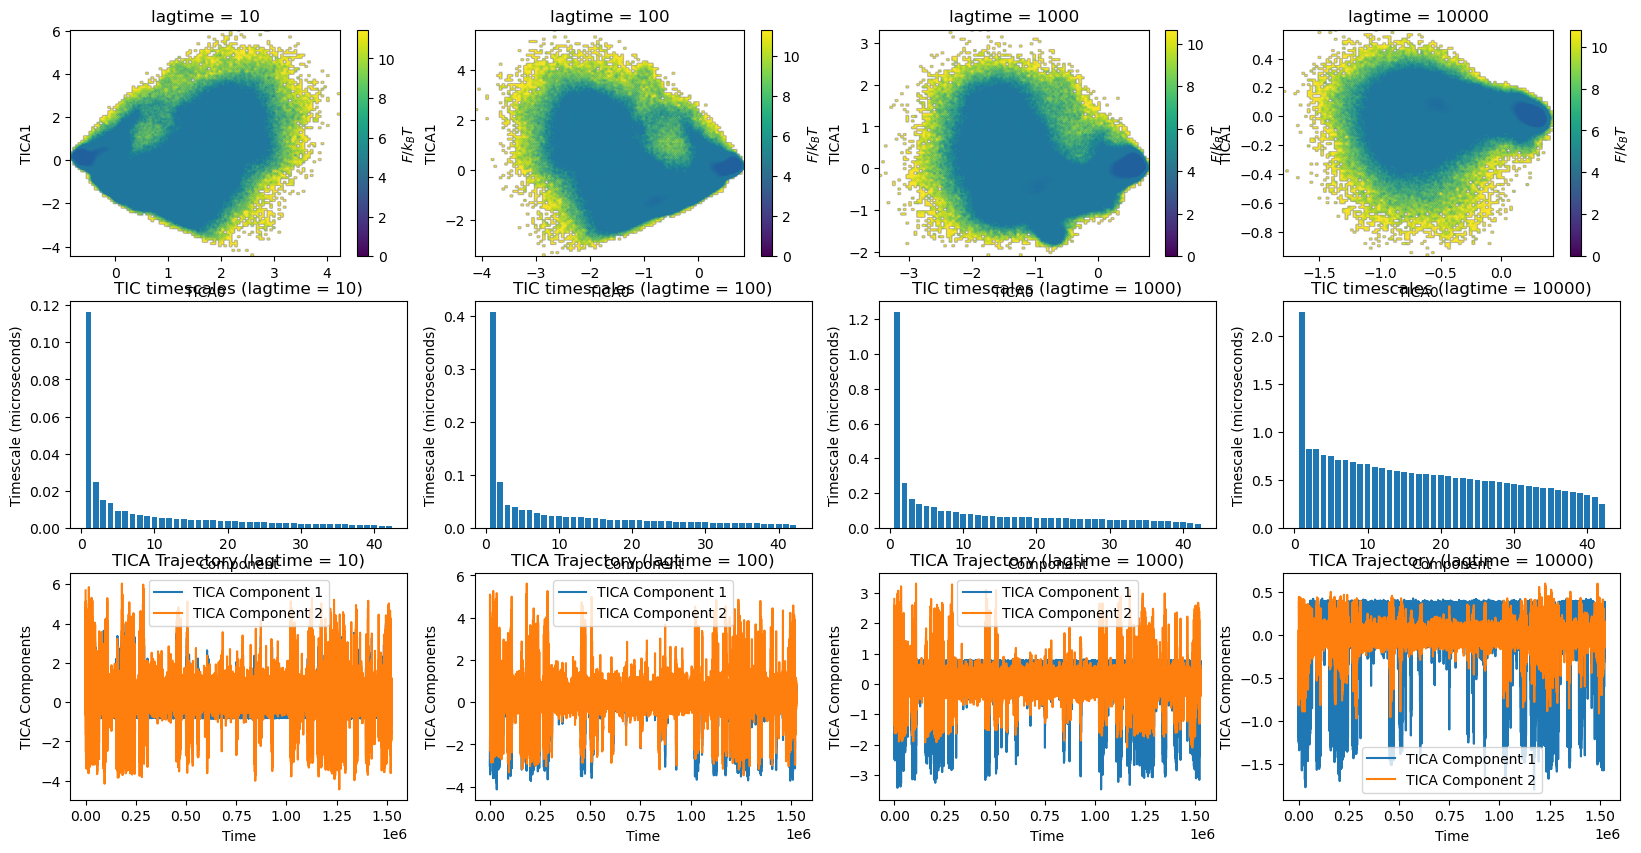

In [ ]:
lagtime_array = [10, 100, 1000, 10000] 

fig, axes = plt.subplots(4, len(lagtime_array), figsize=(30, 10))

for lagtime in lagtime_array:
    ticamodel = TICA(lagtime=lagtime, dim=5)
    ticamodel.fit(X)
    tica_traj = ticamodel.transform(X)
    plot_free_energy_projection(tica_traj, 0, 1, ax = axes[0, lagtime_array.index(lagtime)], axlabel = "TICA", axtitle = f"lagtime = {lagtime}")


    # Plot timescales
    timescales = ticamodel.model.timescales()
    axes[1, lagtime_array.index(lagtime)].bar(range(1, len(timescales) + 1), timescales * time_step_micros)
    axes[1, lagtime_array.index(lagtime)].set_xlabel("Component")
    axes[1, lagtime_array.index(lagtime)].set_ylabel("Timescale (microseconds)")



    # Plot tica trajectory (component 1)
    axes[2, lagtime_array.index(lagtime)].plot(tica_traj[:, 0][:1000], label="TICA Component 1")

    axes[3, lagtime_array.index(lagtime)].plot(tica_traj[:, 1][:1000], label="TICA Component 2")
    axes[3, lagtime_array.index(lagtime)].set_xlabel("Time")
    axes[3, lagtime_array.index(lagtime)].set_ylabel("[nm]")
    axes[3, lagtime_array.index(lagtime)].legend()


In [36]:
# timescale = - lagtime / log(singular_value)

print(ticamodel.model.timescales()[0] * time_step_micros)
print((- ticamodel.model.lagtime / np.log(ticamodel.model.singular_values[0])) * time_step_micros)

2.24913877843119
2.24913877843119


### different normalizations

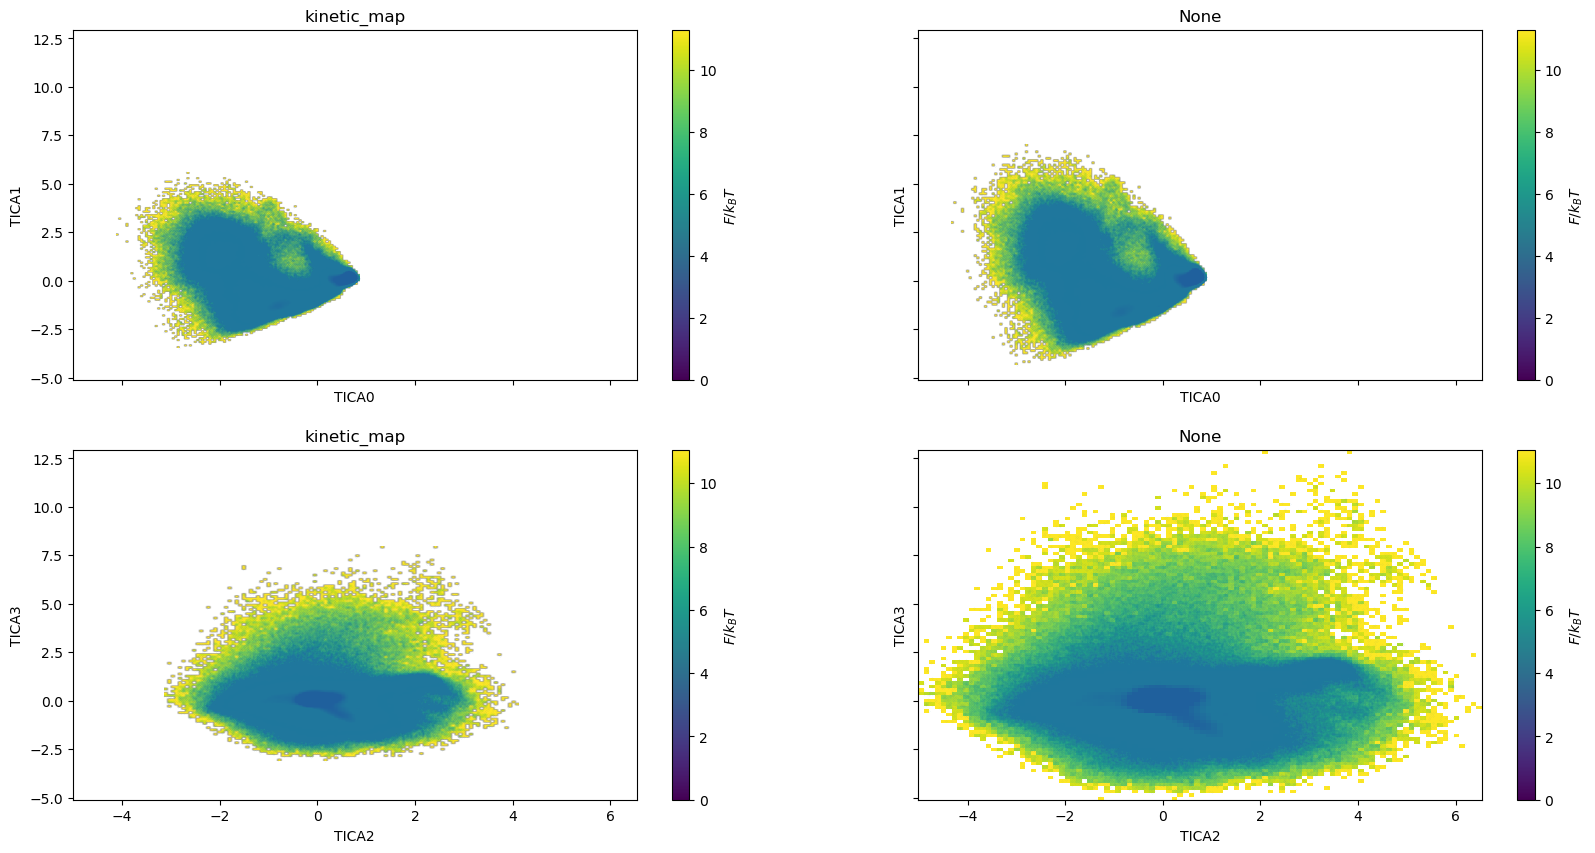

In [52]:
normalization_choices = ["kinetic_map", None]
fig, axes = plt.subplots(2, len(normalization_choices), figsize=(20, 10), sharey=True, sharex=True)

for ax in axes.flatten():
    ax.axis("equal")

tica = TICA(lagtime=100, dim=5)

for scaling_choice in normalization_choices:
    tica.scaling = scaling_choice
    ticamodel = tica.fit(X)
    tica_traj = ticamodel.transform(X)
    plot_free_energy_projection(tica_traj, 0, 1, ax = axes[0, normalization_choices.index(scaling_choice)], axlabel = "TICA", axtitle = f"{ticamodel.scaling}")
    plot_free_energy_projection(tica_traj, 2, 3, ax = axes[1, normalization_choices.index(scaling_choice)], axlabel = "TICA", axtitle = f"{ticamodel.scaling}")

with the kinetic map scaling, the components are stretched as $\hat{z}_i = z_i \cdot \lambda_i$, so that moving in the direction corresponding to the slowest mode increases the distance.

---
#### tICA vs PCA - visualization

<Axes: xlabel='tIC1', ylabel='tIC2'>

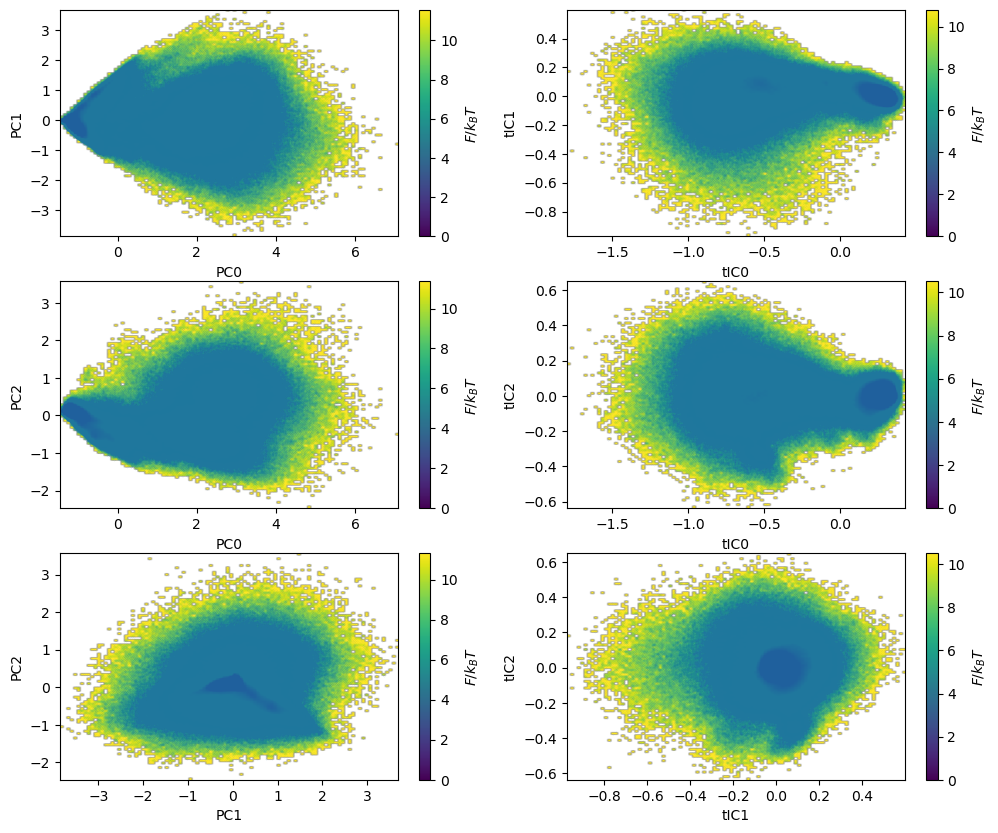

In [27]:
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

plot_free_energy_projection(pca_traj, 0, 1, ax = axs[0, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 0, 1, ax = axs[0, 1], axlabel = "tIC")


plot_free_energy_projection(pca_traj, 0, 2, ax = axs[1, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 0, 2, ax = axs[1, 1], axlabel = "tIC")


plot_free_energy_projection(pca_traj, 1, 2, ax = axs[2, 0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 1, 2, ax = axs[2, 1], axlabel = "tIC")

tICA eigenvalues

### Contacts vs dihedrals - visualization only

<Axes: xlabel='tIC0', ylabel='tIC1'>

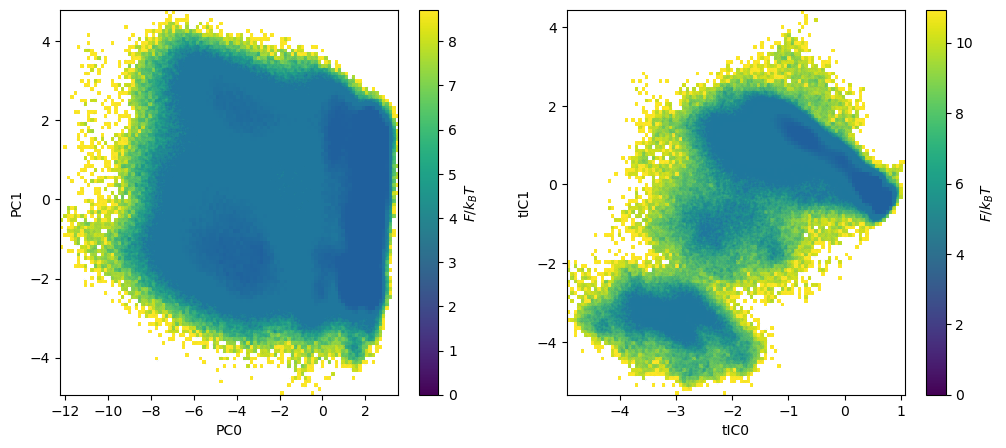

In [55]:
X = dihedrals


# PCA
pca = PCA()
pca.fit(X)
pca_traj = pca.fit_transform(X)


# tICA
tica = TICA(lagtime=100, dim=5)
tica.fit(X)
tica_traj = tica.transform(X)


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plot_free_energy_projection(pca_traj, 0, 1, ax = axs[0], axlabel = "PC")
plot_free_energy_projection(tica_traj, 0, 1, ax = axs[1], axlabel = "tIC")

---
# VAMP2 score for feature set selection: contacts only vs dihedrals only vs both

In [70]:
aggregated_traj = np.concatenate([distances, dihedrals], axis=1)

In [71]:
def make_fit_fetch(dim, lagtime):
    def fit_fetch(trajs):
        vamp = VAMP(dim=dim, lagtime=lagtime)
        vamp.fit(trajs)
        return vamp.fetch_model()
    return fit_fetch


trajs = [[distances], [dihedrals], [aggregated_traj]]  # your raw feature trajectories
traj_names = ["distances", "dihedrals", "aggregated_traj"]
results = {}

for n_vamp in [2,  4, 6,  8,  10]:
    for lagtime in [100, 1000]:
        print(f"Evaluating lagtime = {lagtime}...")
        for i,traj in enumerate(trajs):
            fit_fetch = make_fit_fetch(n_vamp, lagtime)
            scores = vamp_score_cv(fit_fetch, trajs=traj, blocksize=lagtime, n=5, r=2)
            results[(traj_names[i], n_vamp, lagtime)] = scores.mean()
            print(f"features: {traj_names[i]}, dim: {n_vamp}, lagtime={lagtime}: VAMP-2 = {scores.mean():.4f} ± {scores.std():.4f}")

Evaluating lagtime = 100...
features: distances, dim: 2, lagtime=100: VAMP-2 = 2.5449 ± 0.0071
features: dihedrals, dim: 2, lagtime=100: VAMP-2 = 2.7394 ± 0.0067
features: aggregated_traj, dim: 2, lagtime=100: VAMP-2 = 2.7917 ± 0.0052
Evaluating lagtime = 1000...
features: distances, dim: 2, lagtime=1000: VAMP-2 = 1.8936 ± 0.0161
features: dihedrals, dim: 2, lagtime=1000: VAMP-2 = 2.0842 ± 0.0452
features: aggregated_traj, dim: 2, lagtime=1000: VAMP-2 = 2.1055 ± 0.0658
Evaluating lagtime = 100...
features: distances, dim: 4, lagtime=100: VAMP-2 = 3.2965 ± 0.0135
features: dihedrals, dim: 4, lagtime=100: VAMP-2 = 4.1149 ± 0.0068
features: aggregated_traj, dim: 4, lagtime=100: VAMP-2 = 4.2063 ± 0.0103
Evaluating lagtime = 1000...
features: distances, dim: 4, lagtime=1000: VAMP-2 = 1.9798 ± 0.0302
features: dihedrals, dim: 4, lagtime=1000: VAMP-2 = 2.3159 ± 0.0523
features: aggregated_traj, dim: 4, lagtime=1000: VAMP-2 = 2.4774 ± 0.0504
Evaluating lagtime = 100...
features: distances, dim

In [73]:
import pandas as pd

rows = []

for (feature, n_vamp, lag), score in results.items():
    rows.append({
        "feature": feature,
        "n_vamp": n_vamp,
        "lag_frames": lag,
        "score": score,
    })

df = pd.DataFrame(rows)

df.to_csv("intermediate_outputs/vamp_feature_selection.csv", index=False)
df.head()

,feature,n_vamp,lag_frames,score
0,distances,2,100,2.544873
1,dihedrals,2,100,2.739389
2,aggregated_traj,2,100,2.791698
3,distances,2,1000,1.893650
4,dihedrals,2,1000,2.084234


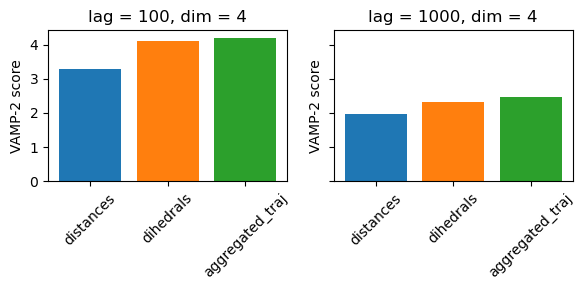

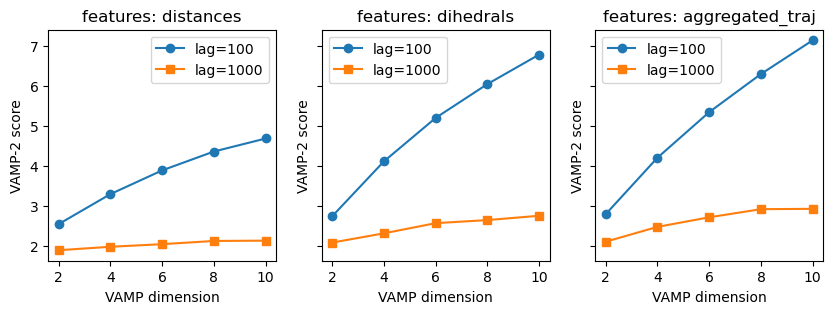

In [83]:
# Bar plot at fixed lag time, dimension


fig, axes = plt.subplots(1, len([100, 1000]), figsize=(6, 3), sharey=True)

colors = cm.tab10.colors
for ax, lag in zip(axes.flatten(), [100, 1000]):

    scores = [results[(feature, 4, lag)] for feature in traj_names]
    ax.bar(traj_names, scores, color=colors[:len(traj_names)])
    ax.set_title(f"lag = {lag}, dim = 4")
    ax.set_ylabel("VAMP-2 score")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()


# Plot as a function of dimension, varying lag time, fixed feauture set
fig, axes = plt.subplots(1, len(traj_names), figsize=(10, 3), sharey=True)
for ax, feature in zip(axes.flatten(), traj_names):

    scores_100 = [results[(feature, n_vamp, 100)] for n_vamp in [2, 4, 6, 8, 10]]
    scores_1000 = [results[(feature, n_vamp, 1000)] for n_vamp in [2, 4, 6, 8, 10]]

    ax.plot([2, 4, 6, 8, 10], scores_100, marker = "o", label="lag=100")
    ax.plot([2, 4, 6, 8, 10], scores_1000, marker = "s", label="lag=1000")
    ax.set_title(f"features: {feature}")
    ax.set_xlabel("VAMP dimension")
    ax.set_ylabel("VAMP-2 score")
    ax.legend()

In [88]:
# More in-depth analysis for dihedrals only, varying lag time and dimension.


trajs = [[dihedrals]]  # your raw feature trajectories
traj_names = ["dihedrals"]
results = {}

for n_vamp in [2, 3, 4, 5, 6, 7, 8,  9, 10]:
    for lagtime in [100, 500, 1000]:
        print(f"Evaluating lagtime = {lagtime}...")
        for i,traj in enumerate(trajs):
            fit_fetch = make_fit_fetch(n_vamp, lagtime)
            scores = vamp_score_cv(fit_fetch, trajs=traj, blocksize=lagtime, n=5, r=2)
            results[(n_vamp, lagtime)] = (scores.mean(), scores.std())
            print(f" dim: {n_vamp}, lagtime={lagtime}: VAMP-2 = {scores.mean():.4f} ± {scores.std():.4f}")





rows = []

for (n_vamp, lag), score in results.items():
    rows.append({
        "n_vamp": n_vamp,
        "lag_frames": lag,
        "score": score[0],
        "std": score[1]
    })

df = pd.DataFrame(rows)

df.to_csv("intermediate_outputs/vamp_feature_selection_dihedrals_only.csv", index=False)
df.head()

Evaluating lagtime = 100...
 dim: 2, lagtime=100: VAMP-2 = 2.7457 ± 0.0062
Evaluating lagtime = 500...
 dim: 2, lagtime=500: VAMP-2 = 2.3891 ± 0.0204
Evaluating lagtime = 1000...
 dim: 2, lagtime=1000: VAMP-2 = 2.0766 ± 0.0270
Evaluating lagtime = 100...
 dim: 3, lagtime=100: VAMP-2 = 3.4760 ± 0.0088
Evaluating lagtime = 500...
 dim: 3, lagtime=500: VAMP-2 = 2.7328 ± 0.0355
Evaluating lagtime = 1000...
 dim: 3, lagtime=1000: VAMP-2 = 2.2309 ± 0.0310
Evaluating lagtime = 100...
 dim: 4, lagtime=100: VAMP-2 = 4.1143 ± 0.0075
Evaluating lagtime = 500...
 dim: 4, lagtime=500: VAMP-2 = 3.0776 ± 0.0377
Evaluating lagtime = 1000...
 dim: 4, lagtime=1000: VAMP-2 = 2.2684 ± 0.0487
Evaluating lagtime = 100...
 dim: 5, lagtime=100: VAMP-2 = 4.6942 ± 0.0363
Evaluating lagtime = 500...
 dim: 5, lagtime=500: VAMP-2 = 3.2799 ± 0.0202
Evaluating lagtime = 1000...
 dim: 5, lagtime=1000: VAMP-2 = 2.5039 ± 0.0401
Evaluating lagtime = 100...
 dim: 6, lagtime=100: VAMP-2 = 5.1664 ± 0.0120
Evaluating lagtim

,n_vamp,lag_frames,score,std
0,2,100,2.745745,0.006162
1,2,500,2.389104,0.020402
2,2,1000,2.076589,0.026969
3,3,100,3.475969,0.008798
4,3,500,2.732816,0.035461


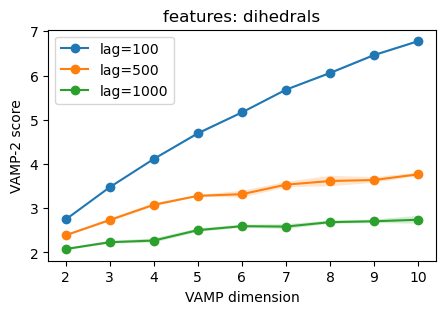

In [89]:
fig, ax = plt.subplots(1, figsize=(5, 3), sharey=True)

for lag in df["lag_frames"].unique():
    temp = df[df["lag_frames"] == lag]
    mean = temp["score"]

    ax.plot(temp["n_vamp"], temp["score"], marker = "o", label=f"lag={lag}")
    ax.fill_between(temp["n_vamp"], temp["score"] - temp["std"], temp["score"] + temp["std"], alpha=0.2)

ax.set_title(f"features: dihedrals")
ax.set_xlabel("VAMP dimension")
ax.set_ylabel("VAMP-2 score")
ax.legend()

---
# Hyperparam selection with VAMP2 score, cross validated

Output: best model for each combination of dim.red. method + feature set. Total: 4 models.

I wont do an extensive grid search because of limited computing resources. 

### first optimize for cluster dimension (is the most cpu intensive step)

In [4]:
output_folder = "intermediate_outputs/vamp_cv/"

feature_name = "distances"
vamp_lag = 500 # ~ 0.1 microseconds. this is an heuristic, but it should suffice to roughly select hyperparameters.
n_dim_list = [5] # intermediate dimension. this is also an heuristic at this stage.

n_clusters_list = [50, 100, 200]

In [5]:
class PCAWrapper:
    """
    Small wrapper that gives sklearn PCA a deeptime-like API:
    fit(...).fetch_model().transform(...).
    """

    def __init__(self, dim: int):
        self.model = PCA(n_components=dim)

    def fit(self, traj):
        self.model.fit(traj)
        return self

    def fetch_model(self):
        return self.model

    def transform(self, X):
        return self.model.transform(X)

In [ ]:
#############################

############################

"""
def make_fit_fetch(n_dim, lagtime, dimred_method = "tICA", n_clusters = 100):

    def fit_fetch(trajs):

        if dimred_method == "PCA":
            pca = PCAWrapper(dim=n_dim)
            pca.fit(np.concatenate(trajs))
            model = pca.fetch_model()

        if dimred_method == "tICA":
            tica = TICA(lagtime=lagtime, dim=n_dim)
            tica.fit(np.concatenate(trajs))
            model = tica.fetch_model()

        # 2. Transform & cluster
        dimred_output = [model.transform(traj) for traj in trajs]
        km = KMeans(n_clusters=n_clusters, max_iter=100, progress=tqdm, n_jobs = 8) #TODO fix njobs!!!
        km.fit(np.concatenate(dimred_output))
        km_model = km.fetch_model()
        dtrajs = [km_model.transform(t) for t in dimred_output]

        # 3. One-hot encode and fit VAMP directly
        def to_onehot(dtraj):
            oh = np.zeros((len(dtraj), n_clusters))
            oh[np.arange(len(dtraj)), dtraj] = 1.0
            return oh

        onehot_trajs = [to_onehot(d) for d in dtrajs]
        vamp = VAMP(lagtime=lagtime, dim=min(n_dim, n_clusters - 1))
        vamp.fit(onehot_trajs)
        return vamp.fetch_model()

    return fit_fetch

trajs = [distances]  # your raw feature trajectories




results = {}
for dimred_method in ["PCA", "tICA"]:
    for n_dim in n_dim_list:
        for n_clusters in n_clusters_list:
            fit_fetch = make_fit_fetch(n_dim = n_dim, dimred_method = dimred_method, n_clusters = n_clusters, lagtime = vamp_lag)
            scores = vamp_score_cv(fit_fetch, trajs=trajs, blocksize=vamp_lag*100, n=5, r=2)
            results[(n_dim, n_clusters, dimred_method, vamp_lag)] = scores.mean()
            print(f"{dimred_method}{n_dim}, clusters={n_clusters}: VAMP-2 = {scores.mean():.4f} ± {scores.std():.4f}")





rows = []
for (n_dim, n_clusters, dimred_method, vamp_lag), score in results.items():
    rows.append({
        "dimred_method": dimred_method,
        "n_clusters": n_clusters,
        "n_dim": n_dim,
        "lag_frames": vamp_lag,
        "mean_score": score[0],
        "std": score[1]
    })

df = pd.DataFrame(rows)

df.to_csv("intermediate_outputs/vamp_cv_nclusters.csv", index=False)
df.head()
"""

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

/Users/miriamzara/miniconda3/envs/MSM_env/lib/python3.11/site-packages/deeptime/clustering/_kmeans.py:466: UserWarning: Algorithm did not reach convergence criterion of 1e-05 in 100 iterations. Consider increasing max_iter.
  warnings.warn(f"Algorithm did not reach convergence criterion"


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, len([100, 1000]), figsize=(6, 3), sharey=True)

colors = cm.tab10.colors


for ax, dim_red_method in zip(axes.flatten(), ["PCA", "tICA"]):
    temp = df[df["dimred_method"] == dim_red_method]


    ax.bar(temp["n_clusters"], temp["mean_score"], color=colors[:len(temp["n_clusters"])])
    ax.set_title(f"{dim_red_method}")
    ax.set_ylabel("VAMP-2 score")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

### PCA + distances

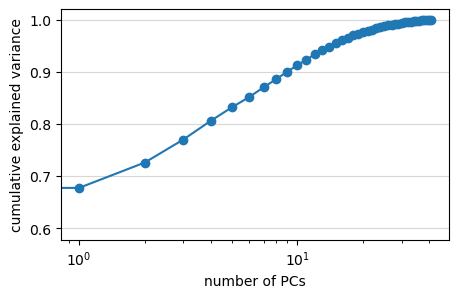

In [92]:
X = distances

pca = PCA()
pca.fit(X)




fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(np.arange(0, len(pca.explained_variance_ratio_)), np.cumsum(pca.explained_variance_ratio_), marker = "o")
ax.set_xscale("log", base = 10)
ax.set_xlabel("number of PCs")
ax.set_ylabel("cumulative explained variance")
ax.grid(axis = "y", alpha = 0.5)